**House Pricing Prediction**

####Libraries


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
# importing minmaxscaler
from sklearn.preprocessing import MinMaxScaler

# importing onehot encoder
from sklearn.preprocessing import OneHotEncoder

####Filepath and dataframe

In [124]:
filepath = "/content/drive/MyDrive/House_Pricing.csv"
df_housepricing = pd.read_csv(filepath)
df_housepricing.head(10)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
5,7237550310,14 May 2017,1230000.0,4,4.50,5420.0,101930.0,1.0,No,NaN,...,10,3890.0,1530,17,0,98053.0,47.6561,-122.005,4760.0,101930
6,1321400060,14 June 2017,257500.0,3,2.25,1715.0,6819.0,2.0,No,NaN,...,7,1715.0,0,23,0,98003.0,47.3097,-122.327,2238.0,6819
7,2008000270,15 January 2016,291850.0,3,1.50,1060.0,9711.0,1.0,No,NaN,...,7,1060.0,0,55,0,98198.0,47.4095,-122.315,1650.0,9711
8,2414600126,15 April 2016,229500.0,3,1.00,1780.0,7470.0,1.0,No,NaN,...,7,1050.0,730,58,0,98146.0,47.5123,-122.337,1780.0,8113
9,3793500160,15 March 2016,323000.0,3,2.50,1890.0,6560.0,2.0,No,NaN,...,7,1890.0,0,15,0,98038.0,47.3684,-122.031,2390.0,7570


####Reading and understanding **data**

In [125]:
df_housepricing.columns

Index(['ID', 'Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [126]:
df_housepricing.shape

(21613, 21)

In [127]:
df_housepricing.size

453873

In [128]:
df_housepricing.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [129]:
df_housepricing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [130]:
df_housepricing.value_counts()

,,,,,,,,,,,,,,,,,,,,,count
ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),
9830200380,14 September 2017,653000.0,3,3.00,3040.0,5067.0,3.0,No,Twice,Fair,10,3040.0,0,25,0,98118.0,47.5409,-122.267,1820.0,5998,1
31000165,14 September 2017,1490000.0,5,3.50,3620.0,7821.0,2.0,No,Twice,Fair,10,2790.0,830,60,2010,98040.0,47.5738,-122.215,2690.0,9757,1
34001160,14 September 2017,590000.0,3,2.00,3030.0,9374.0,1.0,No,Once,Good,7,2100.0,930,59,0,98136.0,47.5289,-122.391,1990.0,6012,1
34001540,15 April 2016,573300.0,2,1.75,1290.0,6600.0,1.0,No,Twice,Fair,7,870.0,420,67,0,98136.0,47.5310,-122.390,2380.0,7370,1
34001765,15 March 2016,699950.0,3,3.25,2230.0,5460.0,1.0,No,Once,Good,8,1430.0,800,41,0,98136.0,47.5300,-122.388,2070.0,5600,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98000130,15 March 2016,1430000.0,4,5.00,4630.0,24054.0,2.0,No,Thrice,Fair,10,4630.0,0,13,0,98075.0,47.5870,-121.966,4630.0,17584,1
91000135,15 May 2016,750000.0,4,1.50,2060.0,4000.0,1.5,No,Twice,Fair,7,1580.0,480,98,1990,98103.0,47.6857,-122.353,1160.0,4000,1
65000400,14 October 2017,570000.0,4,3.00,1490.0,6766.0,1.5,No,Once,Excellent,7,1490.0,0,103,0,98136.0,47.5446,-122.382,1990.0,6526,1


####Missing value handling

In [131]:
df_housepricing.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [132]:
(df_housepricing.isnull().sum()/len(df_housepricing))*100

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581


In [133]:
df_housepricing.drop(columns = ['No of Times Visited'],inplace = True)
#No of time Visited is dropped because more than 90% of the data is missing further imputation will manipulate the data.

In [134]:
df_housepricing.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


In [135]:
df_housepricing = df_housepricing.dropna(subset = ["Zipcode","Flat Area (in Sqft)","Lot Area (in Sqft)","Area of the House from Basement (in Sqft)",'Sale Price','Latitude', 'Longitude', 'Sale Price',"Living Area after Renovation (in Sqft)", "No of Bathrooms"])
#The above removed rows collectively sums uptp <=1 so its removed instead of imputation since it wond make much of any difference.only 33 rows are removed (0.15%aprox.)

In [136]:
df_housepricing.shape

(21580, 20)

In [137]:
df_housepricing.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


####Duplicate Handling

In [138]:
df_housepricing.duplicated().sum()

np.int64(0)

In [139]:
#No duplicates so no need to remove any duplicates

####Outlier Handling

In [140]:
#1. Outliers handling needs to me done only on numerical columns implies Exclude [Waterfront View,ID, condition of the house,Data House was sold].
#2. Zipcode, Latitude, Longitude, Renovated year can be excluded because its either info. or location.
#
#3. Sales needs to be excluded since its a target column.

In [141]:
num_cols = []

In [142]:
num_cols = df_housepricing[['No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)','Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)']]
num_cols

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,1340.0,5650
1,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,1690.0,7639
2,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,2720.0,8062
3,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,1360.0,5000
4,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530.0,1131.0,3.0,8,1530.0,0,9,1530.0,1509
21609,4,2.50,2310.0,5813.0,2.0,8,2310.0,0,4,1830.0,7200
21610,2,0.75,1020.0,1350.0,2.0,7,1020.0,0,9,1020.0,2007
21611,3,2.50,1600.0,2388.0,2.0,8,1600.0,0,14,1410.0,1287


In [143]:
num_cols.columns

Index(['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [144]:
number_of_itr = len(num_cols.columns)

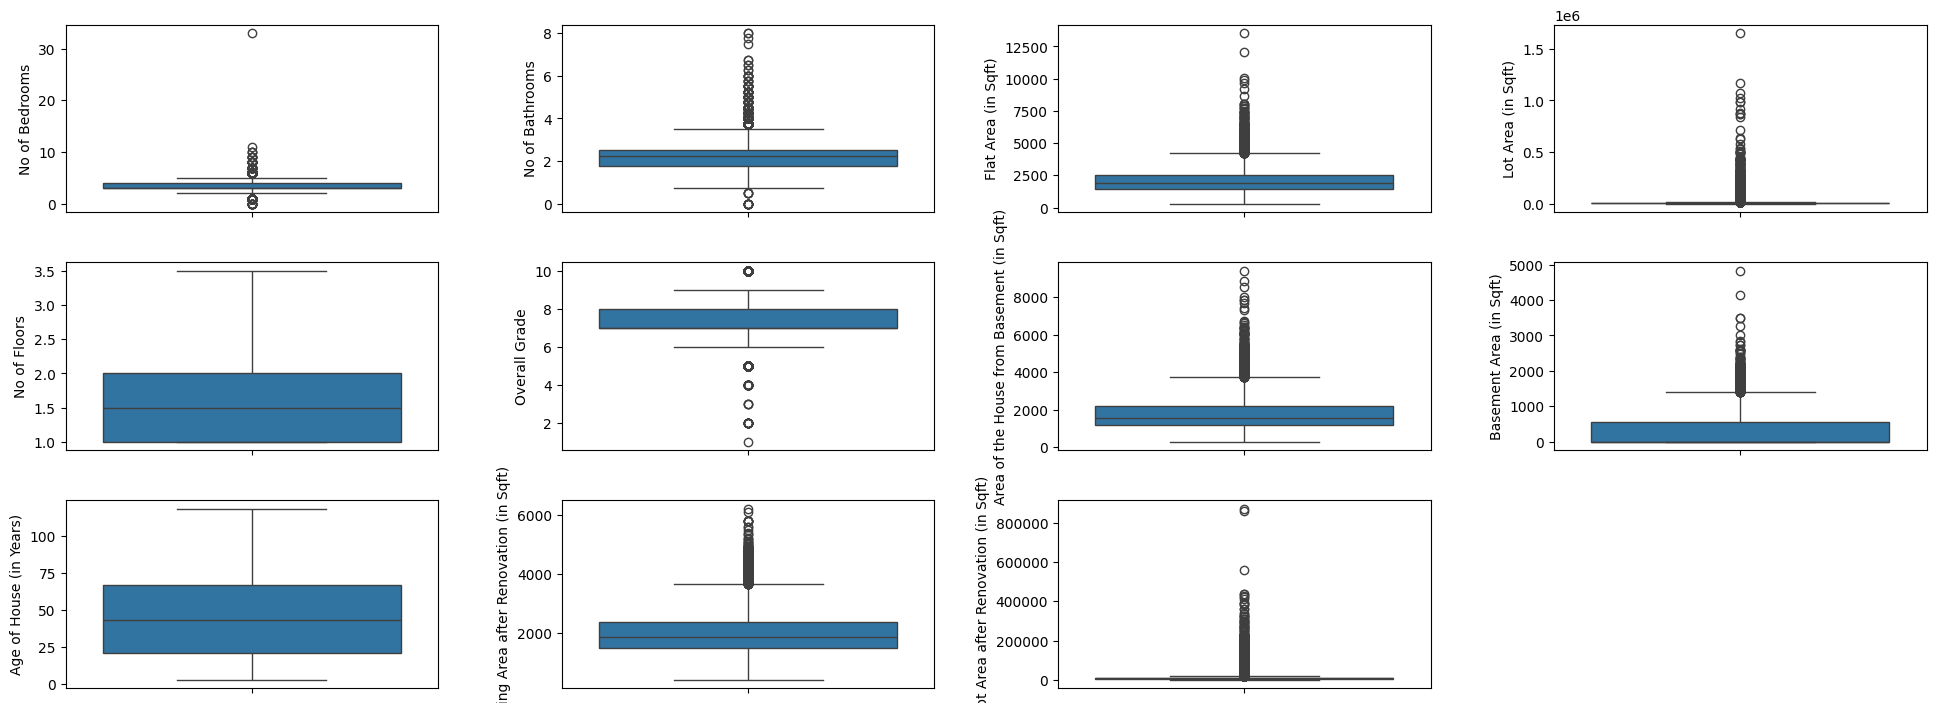

In [145]:
plt.figure(figsize = (20,10))
for i in range(number_of_itr):
  plt.subplot(4,4,i+1)
  sns.boxplot(df_housepricing[num_cols.columns[i]])
plt.tight_layout(pad = 3)
plt.show()

In [146]:
#No. of Bedroom

In [147]:
df_housepricing[['No of Bedrooms','No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)']].describe()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft)
count,21580.000000,21580.000000,21580.000000,2.158000e+04
mean,3.371223,2.114597,2079.896803,1.511585e+04
std,0.930086,0.770140,918.245846,4.144975e+04
min,0.000000,0.000000,290.000000,5.200000e+02
25%,3.000000,1.750000,1430.000000,5.042750e+03
50%,3.000000,2.250000,1910.000000,7.620000e+03
75%,4.000000,2.500000,2550.000000,1.069050e+04
max,33.000000,8.000000,13540.000000,1.651359e+06


In [148]:
# 33 is the major outlier in No of Bedrooms.

In [149]:
df_housepricing[df_housepricing['No of Bedrooms'] > 10]

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
8757,1773100755,14 August 2017,520000.0,11,3.00,3000.0,4960.0,2.0,No,Fair,7,2400.0,600,100,1999,98106.0,47.5560,-122.363,1420.0,4960
15870,2402100895,14 June 2017,640000.0,33,1.75,1620.0,6000.0,1.0,No,Excellent,7,1040.0,580,71,0,98103.0,47.6878,-122.331,1330.0,4700


In [150]:
df_housepricing[df_housepricing['No of Bedrooms'] >= 10][
    ['No of Bedrooms','No of Bathrooms','Flat Area (in Sqft)','Sale Price']
]

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Sale Price
8757,11,3.00,3000.0,520000.0
13314,10,5.25,4590.0,1150000.0
15161,10,2.00,3610.0,650000.0
15870,33,1.75,1620.0,640000.0
19254,10,3.00,2920.0,660000.0


In [151]:
# The value appears to be a data entry error so dropping the row.

In [152]:
df_housepricing = df_housepricing.drop(index = 15870 )

In [153]:
df_housepricing['Lot Area (in Sqft)'].describe()

,Lot Area (in Sqft)
count,2.157900e+04
mean,1.511627e+04
std,4.145067e+04
min,5.200000e+02
25%,5.042500e+03
50%,7.620000e+03
75%,1.069200e+04
max,1.651359e+06


In [154]:
df_housepricing['Lot Area after Renovation (in Sqft)'].describe()

,Lot Area after Renovation (in Sqft)
count,21579.000000
mean,12775.716206
std,27323.300757
min,651.000000
25%,5100.000000
50%,7620.000000
75%,10087.000000
max,871200.000000


In [155]:
df_housepricing[df_housepricing['Lot Area after Renovation (in Sqft)'] >= 400000][
    ['Lot Area after Renovation (in Sqft)','No of Bedrooms','No of Bathrooms','Flat Area (in Sqft)','Sale Price']
]

,Lot Area after Renovation (in Sqft),No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Sale Price
1719,425581,4,1.00,1300.0,700000.0
3801,434728,4,3.50,3080.0,637000.0
6691,411962,2,2.50,3900.0,2000000.0
8664,438213,3,1.75,2930.0,549950.0
9714,871200,4,4.00,5545.0,937500.0
13464,560617,3,2.50,2640.0,790000.0
19156,422967,4,3.50,4370.0,858000.0
20452,858132,4,5.50,6530.0,1600000.0


In [156]:
# Lot area after renovation - Outlier looks genuine scaling needs to be done

In [157]:
#checking Overall Grade
df_housepricing['Overall Grade'].describe()

,Overall Grade
count,21579.000000
mean,7.623291
std,1.105701
min,1.000000
25%,7.000000
50%,7.000000
75%,8.000000
max,10.000000


In [158]:
#No outliers need to handled as the grades are valid and represents Quality of the house.

In [159]:
# Checking number of bathrooms
df_housepricing[['No of Bedrooms','No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)']].describe()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft)
count,21579.000000,21579.000000,21579.000000,2.157900e+04
mean,3.369850,2.114614,2079.918115,1.511627e+04
std,0.907973,0.770154,918.261785,4.145067e+04
min,0.000000,0.000000,290.000000,5.200000e+02
25%,3.000000,1.750000,1430.000000,5.042500e+03
50%,3.000000,2.250000,1910.000000,7.620000e+03
75%,4.000000,2.500000,2550.000000,1.069200e+04
max,11.000000,8.000000,13540.000000,1.651359e+06


In [160]:
df_housepricing[df_housepricing['No of Bathrooms'] > 7][
    ['No of Bathrooms','Lot Area after Renovation (in Sqft)','No of Bedrooms','Flat Area (in Sqft)','Sale Price']
]

,No of Bathrooms,Lot Area after Renovation (in Sqft),No of Bedrooms,Flat Area (in Sqft),Sale Price
7252,8.00,8800,6,12050.0,7700000.0
8546,7.50,3866,9,4050.0,450000.0
9254,7.75,42730,6,9890.0,6890000.0
12777,8.00,217800,7,13540.0,2280000.0


In [161]:
df_housepricing[df_housepricing['No of Bathrooms'] == 0]

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
875,6306400140,14 June 2017,1100000.0,0,0.0,3064.0,4764.0,3.5,No,Fair,7,3064.0,0,28,0,98102.0,47.6362,-122.322,2360.0,4000
1149,3421079032,15 February 2016,75000.0,1,0.0,670.0,43377.0,1.0,No,Fair,3,670.0,0,52,0,98022.0,47.2638,-121.906,1160.0,42882
3119,3918400017,15 February 2016,380000.0,0,0.0,1470.0,979.0,3.0,No,Fair,8,1470.0,0,12,0,98133.0,47.7145,-122.356,1470.0,1399
5832,5702500050,14 November 2017,280000.0,1,0.0,600.0,24501.0,1.0,No,Okay,3,600.0,0,68,0,98045.0,47.5316,-121.749,990.0,22549
6994,2954400190,14 June 2017,1300000.0,0,0.0,4810.0,28008.0,2.0,No,Fair,10,4810.0,0,28,0,98053.0,47.6642,-122.069,4740.0,35061
9773,3374500520,15 April 2016,355000.0,0,0.0,2460.0,8049.0,2.0,No,Fair,8,2460.0,0,28,0,98031.0,47.4095,-122.168,2520.0,8050
9854,7849202190,14 December 2017,235000.0,0,0.0,1470.0,4800.0,2.0,No,Fair,7,1470.0,0,22,0,98065.0,47.5265,-121.828,1060.0,7200
10481,203100435,14 September 2017,484000.0,1,0.0,690.0,23244.0,1.0,No,Good,7,690.0,0,70,0,98053.0,47.6429,-121.955,1690.0,19290
14423,9543000205,15 April 2016,139950.0,0,0.0,844.0,4269.0,1.0,No,Good,7,844.0,0,105,0,98001.0,47.2781,-122.250,1380.0,9600
19452,3980300371,14 September 2017,142000.0,0,0.0,290.0,20875.0,1.0,No,Bad,1,290.0,0,55,0,98024.0,47.5308,-121.888,1620.0,22850


In [162]:
#Outliers appear genuine and likely represent large properties. Will evaluate skewness and transformation later.

In [163]:
df_housepricing[df_housepricing["No of Floors"]>=2]

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
6,1321400060,14 June 2017,257500.0,3,2.25,1715.0,6819.0,2.0,No,Fair,7,1715.0,0,23,0,98003.0,47.3097,-122.327,2238.0,6819
9,3793500160,15 March 2016,323000.0,3,2.50,1890.0,6560.0,2.0,No,Fair,7,1890.0,0,15,0,98038.0,47.3684,-122.031,2390.0,7570
15,9297300055,15 January 2016,650000.0,4,3.00,2950.0,5000.0,2.0,No,Fair,9,1980.0,970,39,0,98126.0,47.5714,-122.375,2140.0,4000
16,1875500060,14 July 2017,395000.0,3,2.00,1890.0,14040.0,2.0,No,Fair,7,1890.0,0,24,0,98019.0,47.7277,-121.962,1890.0,14018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [164]:
# In the rest of the data #Outliers appear genuine and likely represent large properties. Will evaluate skewness and transformation later.

####Scaling





In [165]:
num_cols.columns

Index(['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [166]:

num_col2.shape

(21580, 10)

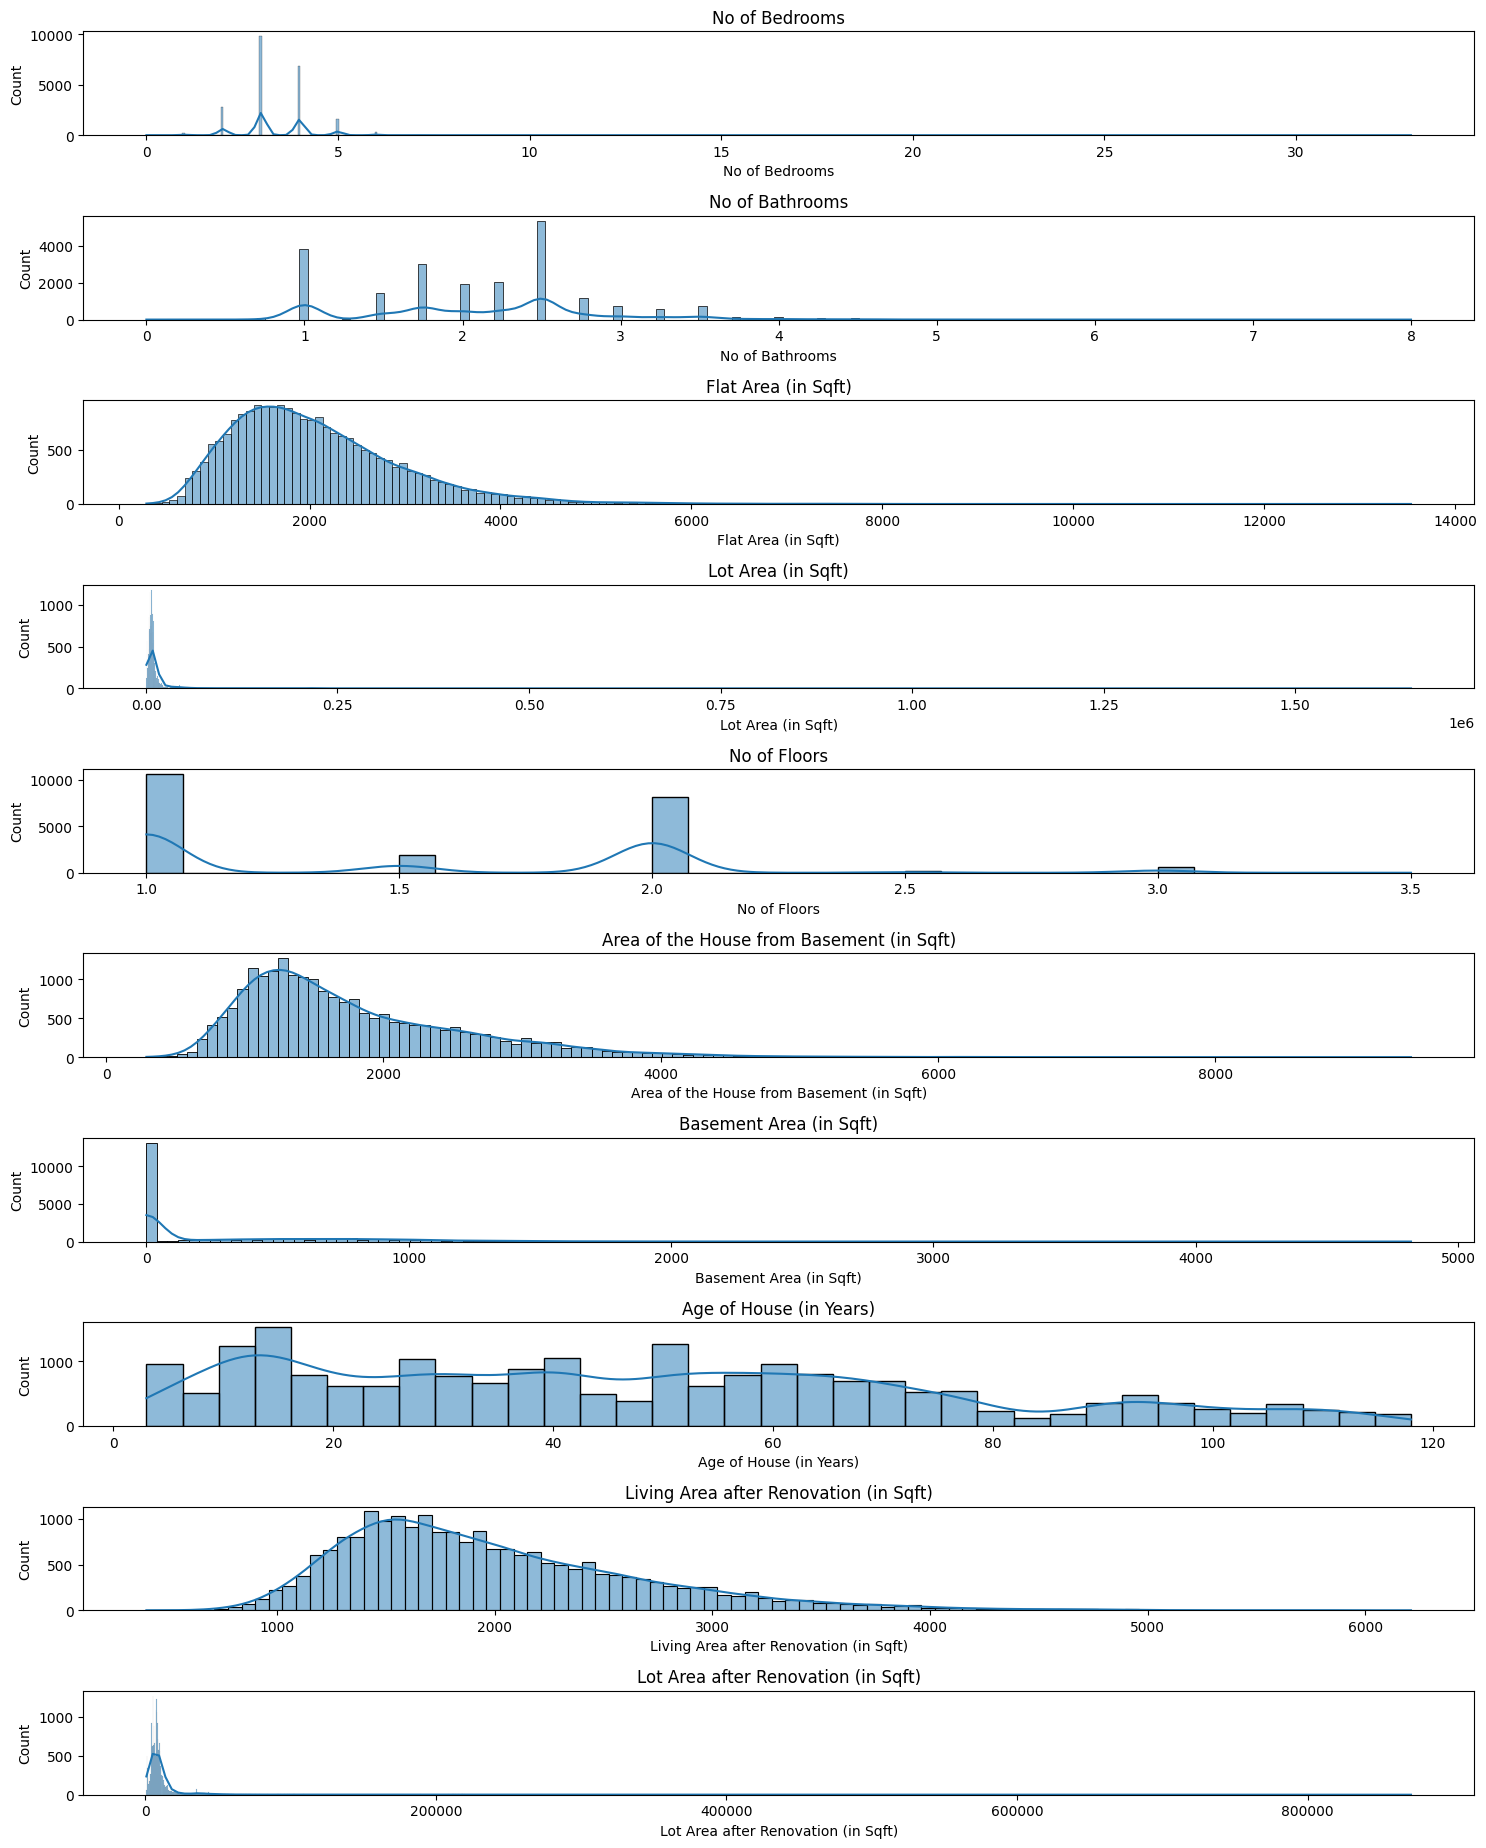

In [167]:
plt.figure(figsize=(15,20))

i= 1
for column in num_col2 :
  plt.subplot(11,1,i)
  sns.histplot(num_col2[column],kde = True)
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [168]:
#All columns are right skewed, hence applying minmax scaler for all numerical columns.

In [172]:
minmaxscaler = MinMaxScaler() # creating an object
df_housepricing[num_cols.columns] = minmaxscaler.fit_transform(df_housepricing[num_cols.columns]) # transforming numerical columns

####Encoding

In [173]:
cat_col = df_housepricing.drop(columns = num_cols.columns) # taking all columns which are not numerical
cat_col = cat_col.drop(['ID','Date House was Sold'],axis =1) # dropping the column of ID as it is an identifier and 'Date House was Sold' as it doesnt need encoding

In [174]:
cat_col.columns # checking the names of categorical columns

# all columns are non- binary. Hnece proceeding with one hot encoding

Index(['Sale Price', 'Waterfront View', 'Condition of the House',
       'Renovated Year', 'Zipcode', 'Latitude', 'Longitude'],
      dtype='object')

In [176]:
df_housepricing = pd.get_dummies(df_housepricing, columns = cat_col.columns ,dtype = int)
df_housepricing

,ID,Date House was Sold,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Longitude_-121.403,Longitude_-121.402,Longitude_-121.364,Longitude_-121.359,Longitude_-121.352,Longitude_-121.325,Longitude_-121.321,Longitude_-121.319,Longitude_-121.316,Longitude_-121.315
0,7129300520,14 October 2017,0.272727,0.12500,0.067170,0.003108,0.0,0.666667,0.097588,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,6414100192,14 December 2017,0.272727,0.28125,0.172075,0.004072,0.4,0.666667,0.206140,0.082988,...,0,0,0,0,0,0,0,0,0,0
2,5631500400,15 February 2016,0.181818,0.12500,0.036226,0.005743,0.0,0.555556,0.052632,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,2487200875,14 December 2017,0.363636,0.37500,0.126038,0.002714,0.0,0.666667,0.083333,0.188797,...,0,0,0,0,0,0,0,0,0,0
4,1954400510,15 February 2016,0.272727,0.25000,0.104906,0.004579,0.0,0.777778,0.152412,0.000000,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,0.272727,0.31250,0.093585,0.000370,0.8,0.777778,0.135965,0.000000,...,0,0,0,0,0,0,0,0,0,0
21609,6600060120,15 February 2016,0.363636,0.31250,0.152453,0.003206,0.4,0.777778,0.221491,0.000000,...,0,0,0,0,0,0,0,0,0,0
21610,1523300141,14 June 2017,0.181818,0.09375,0.055094,0.000503,0.4,0.666667,0.080044,0.000000,...,0,0,0,0,0,0,0,0,0,0
21611,291310100,15 January 2016,0.272727,0.31250,0.098868,0.001132,0.4,0.777778,0.143640,0.000000,...,0,0,0,0,0,0,0,0,0,0
